# Case Study Analysis

This notebook is set up for exploring `Analyst_case_study_dataset.xls`.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [5]:
import sys
!{sys.executable} -m pip install xlrd statsmodels

  Obtaining dependency information for xlrd from https://files.pythonhosted.org/packages/1a/62/c8d562e7766786ba6587d09c5a8ba9f718ed3fa8af7f4553e8f91c36f302/xlrd-2.0.2-py2.py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.6/96.6 kB 6.6 MB/s eta 0:00:00


In [35]:
!{sys.executable} -m pip install xlrd statsmodels

  Obtaining dependency information for statsmodels from https://files.pythonhosted.org/packages/a9/4d/df4dd089b406accfc3bb5ee53ba29bb3bdf5ae61643f86f8f604baa57656/statsmodels-0.14.6-cp311-cp311-macosx_10_9_x86_64.whl.metadata
  Obtaining dependency information for patsy>=0.5.6 from https://files.pythonhosted.org/packages/f1/70/ba4b949bdc0490ab78d545459acd7702b211dfccf7eb89bbc1060f52818d/patsy-1.0.2-py2.py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 11.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 16.0 MB/s eta 0:00:00


In [74]:
file_path = 'Analyst_case_study_dataset.xls'
df = pd.read_excel(file_path)

initial_rows = len(df)
duplicate_vendor_lead_id_rows = df['VendorLeadID'].notna() & df.duplicated(subset='VendorLeadID', keep='first')
df = df.loc[~duplicate_vendor_lead_id_rows].copy()
df = df.drop(columns='IP Address')
df['Partner'] = df['Partner'].str.strip().str.capitalize()

debt_level_map = {
    '7500-10000': '7500-15000',
    '10001-15000': '7500-15000',
    '7500-15000': '7500-15000',
    '15001-20000': '15001-30000',
    '20001-30000': '15001-30000',
    '30001-50000': '30001-50000',
    '50001-70000': '50001-90000',
    '70001-90000': '50001-90000',
    '90000-100000': '90000+',
    'More_than_100000': '90000+'
}
df['DebtLevelClean'] = df['DebtLevel'].map(debt_level_map)

widget_parts = df['WidgetName'].str.split('-', expand=True)
df['WidgetSizeRaw'] = widget_parts[1]
df['WidgetSizeGroup'] = df['WidgetSizeRaw'].replace({'300250': '300250/302252', '302252': '300250/302252'})
df['WidgetFieldset'] = widget_parts[2]
df['WidgetPageType'] = widget_parts[3]
df['WidgetDesign'] = widget_parts[4].fillna('Base')
df['WidgetColor'] = widget_parts[5].fillna('None')

print(f'Removed {duplicate_vendor_lead_id_rows.sum()} duplicate VendorLeadID row(s).')
print('Dropped IP Address column.')
print('Standardized Partner values.')
print('Created DebtLevelClean groups.')
print('Parsed WidgetName into component fields.')
print(f'Rows before cleaning: {initial_rows}')
print(f'Rows after cleaning: {len(df)}')

df.head()

Removed 1 duplicate VendorLeadID row(s).
Dropped IP Address column.
Standardized Partner values.
Created DebtLevelClean groups.
Rows before cleaning: 3021
Rows after cleaning: 3020


,LeadCreated,FirstName,Email,VendorLeadID,CallStatus,WidgetName,PublisherZoneName,PublisherCampaignName,AddressScore,PhoneScore,AdvertiserCampaignName,State,DebtLevel,Partner,ReferralDomain,MarketingCampaign,AdGroup,Keyword,SearchQuery,ReferralURL,ReferralURL Parameters,LandingPageURL,Landing Page URL Parameters,DebtLevelClean
0,2009-07-01 01:24:29.563,Dorinda,kanani@sandwichisles.net,FDF81FDA-A649-437B-B99C-FDDE74F7971B,NaN,w-302252-DebtReduction1-1DC-CreditSolutions,TopLeft-302252,DebtReductionInc,NaN,5.0,creditsolutions-branded-shortform,HI,30001-50000,Google,www.google.com,Debt Holding Tank,Holding Tank - Debt,Debt specialists,debt specialists,http://www.google.com/search,sourceid=navclient&aq=1&oq=debt sp&ie=UTF-8&rl...,http://www.debtreductioninc.com/index8.html,utm_source=google&utm_medium=CPC&utm_content=H...,30001-50000
1,2009-04-13 15:27:35.990,Presetta,clerk2@ustconline.net,4190ACB7-5026-416C-B987-ED8AD427D5E6,NaN,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,AL,90000-100000,Adknowledge,NaN,Financial Services,Consolidate,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...,90000+
2,2009-04-21 07:22:59.000,Gina,wagoner_gina@yahoo.com,hFg80jf_R0CRN55hdhWILw,Unable to contact - Bad Contact Information,w-300250-DebtReduction1-1DC-Head2,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,NY,20001-30000,Adknowledge,us.mc582.mail.yahoo.com,Financial Services,Consolidate,NaN,NaN,http://us.mc582.mail.yahoo.com/mc/showMessage,&fid=Inbox&sort=date&order=down&startMid=0&.ra...,http://www.debtreductioninc.com/index8.html,utm_source=AdKnowledge&utm_medium=CPC&utm_cont...,15001-30000
3,2009-08-03 19:39:02.000,Kari,usa4ley@yahoo.com,jB01QgYZxkWArI9jWxuufw,Contacted - Doesn't Qualify,w-302252-DebtReduction1-1DC-white,TopLeft-302252,DebtReductionInc,5.0,3.0,Debt Settlement1 Master,WA,20001-30000,Google,norwich.kijiji.com,DebtReductionInc,Lower Payments,NaN,NaN,http://norwich.kijiji.com/c-Cars-vehicles-Cars...,NaN,http://www.debtreductioninc.com/index12.html,utm_source=Google&utm_medium=cpc&utm_campaign=...,15001-30000
4,2009-04-13 10:18:37.490,Stephanie,sr1lambert@embarqmail.com,D5B32074-458E-40EC-B185-1FEF20AC626D,NaN,w-300250-DebtReduction1-1DC-BlueMeter,TopLeft-302252,DebtReductionInc,NaN,NaN,Debt Settlement1 Master,TX,More_than_100000,Google,NaN,DebtReductionInc,Debt Reduction,NaN,NaN,NaN,NaN,http://www.debtreductioninc.com/index8.html,utm_source=Google&utm_medium=cpc&utm_campaign=...,90000+


In [75]:
good_statuses = {'EP Sent', 'EP Received', 'EP Confirmed'}
bad_statuses = {
    "Contacted - Doesn't Qualify",
    'Contacted - Invalid Profile',
    'Unable to contact - Bad Contact Information'
}

def group_call_status(status):
    if pd.isna(status):
        return 'Unknown'
    if status == 'Closed':
        return 'Closed'
    if status in good_statuses:
        return 'Good Lead Quality'
    if status in bad_statuses:
        return 'Bad Lead Quality'
    return 'Unknown'

if 'CallStatusGroup' in df.columns:
    df = df.drop(columns='CallStatusGroup')

call_status_position = df.columns.get_loc('CallStatus') + 1
df.insert(call_status_position, 'CallStatusGroup', df['CallStatus'].apply(group_call_status))

df[['CallStatus', 'CallStatusGroup']].value_counts(dropna=False)

CallStatus                                   CallStatusGroup  
NaN                                          Unknown              2139
Closed                                       Closed                245
Contacted - Doesn't Qualify                  Bad Lead Quality      212
Unable to contact - Bad Contact Information  Bad Lead Quality      191
EP Confirmed                                 Good Lead Quality     130
Contacted - Invalid Profile                  Bad Lead Quality       85
EP Sent                                      Good Lead Quality      16
EP Received                                  Good Lead Quality       2
Name: count, dtype: int64

## Lead Quality Trends Over Time

For the first pass, lead quality is defined as `Closed Rate`.

`Closed Rate = number of Closed leads / total number of leads`

We will also track a broader positive quality rate:

`Positive Quality Rate = number of Closed or Good Lead Quality leads / total number of leads`

We will start by looking at this metric weekly.

### Is lead quality improving or declining?

In [128]:
df['LeadCreatedDate'] = pd.to_datetime(df['LeadCreated']).dt.date
df['LeadCreatedWeek'] = pd.to_datetime(df['LeadCreated']).dt.to_period('W').dt.start_time
df['IsClosed'] = (df['CallStatusGroup'] == 'Closed').astype(int)
df['IsPositiveQuality'] = df['CallStatusGroup'].isin(['Closed', 'Good Lead Quality']).astype(int)
df['IsBadQuality'] = (df['CallStatusGroup'] == 'Bad Lead Quality').astype(int)

weekly_quality = (
    df.groupby('LeadCreatedWeek')
    .agg(
        leads=('IsClosed', 'size'),
        closed_leads=('IsClosed', 'sum'),
        closed_rate=('IsClosed', 'mean'),
        positive_quality_leads=('IsPositiveQuality', 'sum'),
        positive_quality_rate=('IsPositiveQuality', 'mean'),
        bad_quality_leads=('IsBadQuality', 'sum'),
        bad_quality_rate=('IsBadQuality', 'mean')
    )
    .reset_index()
)

weekly_quality['closed_rate_pct'] = weekly_quality['closed_rate'] * 100
weekly_quality['positive_quality_rate_pct'] = weekly_quality['positive_quality_rate'] * 100
weekly_quality['bad_quality_rate_pct'] = weekly_quality['bad_quality_rate'] * 100
weekly_quality.head()

,LeadCreatedWeek,leads,closed_leads,closed_rate,positive_quality_leads,positive_quality_rate,bad_quality_leads,bad_quality_rate,closed_rate_pct,positive_quality_rate_pct,bad_quality_rate_pct
0,2009-03-30,37,3,0.081081,6,0.162162,3,0.081081,8.108108,16.216216,8.108108
1,2009-04-06,119,15,0.126050,18,0.151261,9,0.075630,12.605042,15.126050,7.563025
2,2009-04-13,125,16,0.128000,21,0.168000,10,0.080000,12.800000,16.800000,8.000000
3,2009-04-20,155,14,0.090323,25,0.161290,22,0.141935,9.032258,16.129032,14.193548
4,2009-04-27,129,10,0.077519,14,0.108527,14,0.108527,7.751938,10.852713,10.852713


#### Overall Lead Quality Scores

Before looking at weekly trends, check the overall average for the three lead quality measures.

In [129]:
overall_quality_scores = pd.DataFrame({
    'metric': [
        'Closed Rate',
        'Closed + Good Lead Quality Rate',
        'Bad Lead Quality Rate'
    ],
    'leads': [
        df['IsClosed'].sum(),
        df['IsPositiveQuality'].sum(),
        df['IsBadQuality'].sum()
    ],
    'rate_pct': [
        df['IsClosed'].mean() * 100,
        df['IsPositiveQuality'].mean() * 100,
        df['IsBadQuality'].mean() * 100
    ]
})

overall_quality_scores

,metric,leads,rate_pct
0,Closed Rate,245,8.112583
1,Closed + Good Lead Quality Rate,393,13.013245
2,Bad Lead Quality Rate,488,16.158940


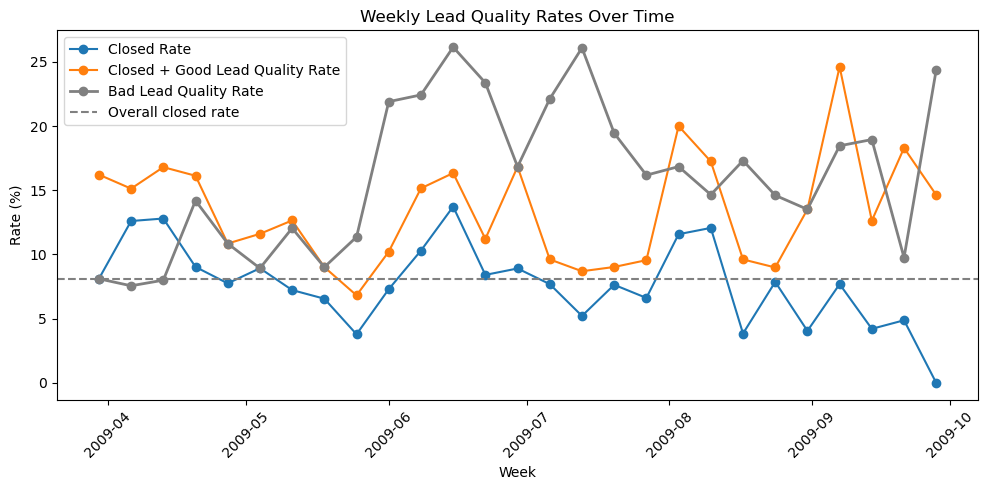

In [130]:
plt.figure(figsize=(10, 5))
plt.plot(
    weekly_quality['LeadCreatedWeek'],
    weekly_quality['closed_rate_pct'],
    marker='o',
    label='Closed Rate'
)
plt.plot(
    weekly_quality['LeadCreatedWeek'],
    weekly_quality['positive_quality_rate_pct'],
    marker='o',
    label='Closed + Good Lead Quality Rate'
)
plt.plot(
    weekly_quality['LeadCreatedWeek'],
    weekly_quality['bad_quality_rate_pct'],
    marker='o',
    color='gray',
    linewidth=2,
    label='Bad Lead Quality Rate'
)
plt.axhline(df['IsClosed'].mean() * 100, color='gray', linestyle='--', label='Overall closed rate')
plt.title('Weekly Lead Quality Rates Over Time')
plt.xlabel('Week')
plt.ylabel('Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Weekly Lead Volume

Before interpreting the weekly rates, check how many leads are included in each week.

In [45]:
weekly_quality[['LeadCreatedWeek', 'leads', 'closed_leads', 'positive_quality_leads', 'bad_quality_leads']]

,LeadCreatedWeek,leads,closed_leads,positive_quality_leads,bad_quality_leads
0,2009-03-30,37,3,6,3
1,2009-04-06,119,15,18,9
2,2009-04-13,125,16,21,10
3,2009-04-20,155,14,25,22
4,2009-04-27,129,10,14,14
5,2009-05-04,112,10,13,10
6,2009-05-11,166,12,21,20
7,2009-05-18,122,8,11,11
8,2009-05-25,132,5,9,15
9,2009-06-01,137,10,14,30


### Initial Observation

Based on the weekly trend analysis, lead quality does not move in one clean direction.

The strict success metric, Closed Rate, appears to weaken over time. It starts around 12% in early April, rebounds in June and early August, but many later weeks fall below the overall closed rate benchmark.

However, the broader Positive Quality Rate, which includes both Closed and Good Lead Quality leads, appears to improve later in the period, with several stronger weeks in August and September. At the same time, Bad Lead Quality Rate also increases around June and remains elevated, suggesting that the lead mix may have become more polarized: more leads show some positive intermediate signal, but more leads are also being classified as bad quality.

A large share of leads fall into the Unknown group, which makes the explicit quality signals sparse and contributes to week-to-week volatility. The first and last weeks also have much lower lead volume, so those edge weeks should be interpreted cautiously.

Overall, the visual evidence is mixed. Closed Rate appears to decline, Positive Quality Rate appears to improve, and Bad Lead Quality Rate appears to increase. Therefore, I would not conclude that lead quality is clearly improving or clearly declining from the chart alone. A statistical trend test is needed to determine whether these apparent patterns are significant.

### Are those trends statistically significant?

To test whether the visual trends are statistically significant, use a lead-level logistic regression with time as the predictor.

Each outcome is binary: `1` if the lead belongs to that category and `0` otherwise. The time variable is `days_since_start`, which measures how many days passed since the first lead in the dataset.

The model is:

`Outcome ~ days_since_start`

A positive coefficient means that outcome became more likely over time. A negative coefficient means it became less likely over time. A p-value below 0.05 suggests the time trend is statistically significant at the 5% level.

In [85]:
import statsmodels.api as sm

trend_df = df[['LeadCreated', 'IsClosed', 'IsPositiveQuality', 'IsBadQuality']].copy()
trend_df['days_since_start'] = (
    pd.to_datetime(trend_df['LeadCreated']) - pd.to_datetime(trend_df['LeadCreated']).min()
).dt.days

def test_time_trend(outcome_col, quality_interpretation):
    X = sm.add_constant(trend_df['days_since_start'])
    y = trend_df[outcome_col]
    model = sm.Logit(y, X).fit(disp=False)

    coef = model.params['days_since_start']
    p_value = model.pvalues['days_since_start']
    if coef > 0:
        statistical_direction = 'Increasing over time'
    else:
        statistical_direction = 'Decreasing over time'

    return {
        'metric': outcome_col,
        'quality_interpretation': quality_interpretation,
        'time_coefficient': coef,
        'p_value': p_value,
        'statistical_direction': statistical_direction,
        'statistically_significant_5pct': p_value < 0.05
    }

trend_results = pd.DataFrame([
    test_time_trend('IsClosed', 'Higher is better'),
    test_time_trend('IsPositiveQuality', 'Higher is better'),
    test_time_trend('IsBadQuality', 'Higher is worse')
])

trend_results

,metric,quality_interpretation,time_coefficient,p_value,statistical_direction,statistically_significant_5pct
0,IsClosed,Higher is better,-0.003682,0.007262,Decreasing over time,True
1,IsPositiveQuality,Higher is better,0.000282,0.795354,Increasing over time,False
2,IsBadQuality,Higher is worse,0.003321,0.000787,Increasing over time,True


### Statistical Significance Conclusion

The logistic regression trend test shows that some of the time trends are statistically significant.

Closed Rate has a negative time coefficient and is statistically significant at the 5% level (`p = 0.007`). This means the probability of a lead becoming Closed declines over time.

Bad Lead Quality Rate has a positive time coefficient and is also statistically significant at the 5% level (`p = 0.001`). This means bad-quality outcomes become more likely over time.

Positive Quality Rate has a slightly positive time coefficient, but it is not statistically significant (`p = 0.795`). Therefore, we do not have statistical evidence that the broader positive quality rate is truly increasing over time.

Overall, the statistically significant results point toward worsening lead quality over time: Closed Rate declines significantly, while Bad Lead Quality Rate increases significantly.

## Drivers of Lead Quality

This section compares lead quality across segments related to where the ad was shown, what kind of person filled out the ad, and what kind of ad creative they saw.

For each segment, we will compare lead volume, Closed Rate, Positive Quality Rate, Bad Lead Quality Rate, and Unknown Rate.

In [86]:
def segment_summary(segment_col, min_leads=20):
    required_indicator_map = {
        'IsClosed': df['CallStatusGroup'] == 'Closed',
        'IsPositiveQuality': df['CallStatusGroup'].isin(['Closed', 'Good Lead Quality']),
        'IsBadQuality': df['CallStatusGroup'] == 'Bad Lead Quality',
        'IsUnknown': df['CallStatusGroup'] == 'Unknown'
    }

    for indicator_col, condition in required_indicator_map.items():
        if indicator_col not in df.columns:
            df[indicator_col] = condition.astype(int)

    summary = (
        df.groupby(segment_col, dropna=False)
        .agg(
            leads=('CallStatusGroup', 'size'),
            closed_leads=('IsClosed', 'sum'),
            closed_rate=('IsClosed', 'mean'),
            positive_quality_leads=('IsPositiveQuality', 'sum'),
            positive_quality_rate=('IsPositiveQuality', 'mean'),
            bad_quality_leads=('IsBadQuality', 'sum'),
            bad_quality_rate=('IsBadQuality', 'mean'),
            unknown_leads=('IsUnknown', 'sum'),
            unknown_rate=('IsUnknown', 'mean')
        )
        .reset_index()
    )

    rate_cols = ['closed_rate', 'positive_quality_rate', 'bad_quality_rate', 'unknown_rate']
    summary[rate_cols] = summary[rate_cols] * 100
    summary = summary[summary['leads'] >= min_leads].copy()
    return summary.sort_values(['closed_rate', 'leads'], ascending=[False, False])


### Initial Segment Checks

Start with a few high-level fields that map directly to the business question.

In [87]:
segment_summary('PublisherCampaignName')

,PublisherCampaignName,leads,closed_leads,closed_rate,positive_quality_leads,positive_quality_rate,bad_quality_leads,bad_quality_rate,unknown_leads,unknown_rate
0,DebtReductionCallCenter,271,26,9.594096,44,16.236162,66,24.354244,161,59.409594
1,DebtReductionInc,2749,219,7.966533,349,12.695526,422,15.351037,1978,71.953438


In [88]:
segment_summary('Partner')

,Partner,leads,closed_leads,closed_rate,positive_quality_leads,positive_quality_rate,bad_quality_leads,bad_quality_rate,unknown_leads,unknown_rate
0,Adknowledge,171,21,12.280702,32,18.713450,23,13.450292,116,67.836257
2,Call_center,271,26,9.594096,44,16.236162,66,24.354244,161,59.409594
4,Yahoo,957,74,7.732497,136,14.211076,147,15.360502,674,70.428422
3,Google,1618,123,7.601978,180,11.124845,252,15.574784,1186,73.300371


#### Publisher Campaign and Partner Overlap

`PublisherCampaignName = DebtReductionCallCenter` and `Partner = Call_center` appear to describe the same group of 271 leads. The lead counts and quality rates match exactly across the two summaries.

This means the call center pattern should not be interpreted as two independent drivers. It is better understood as one acquisition mode: leads created by people calling an 800 number and having call center staff enter the form information. When interpreting `Partner`, the `Call_center` row overlaps with the call center publisher campaign, while the other rows compare advertising partners such as Google, Yahoo, and Adknowledge.

In [89]:
df[['DebtLevel', 'DebtLevelClean']].drop_duplicates().sort_values(['DebtLevelClean', 'DebtLevel'])

,DebtLevel,DebtLevelClean
12,15001-20000,15001-30000
2,20001-30000,15001-30000
0,30001-50000,30001-50000
15,50001-70000,50001-90000
6,70001-90000,50001-90000
5,10001-15000,7500-15000
17,7500-10000,7500-15000
7,7500-15000,7500-15000
1,90000-100000,90000+
4,More_than_100000,90000+


In [90]:
df['DebtLevelClean'].value_counts().sort_index()

DebtLevelClean
15001-30000     864
30001-50000     496
50001-90000     376
7500-15000     1004
90000+          280
Name: count, dtype: int64

In [91]:
segment_summary('DebtLevelClean')

,DebtLevelClean,leads,closed_leads,closed_rate,positive_quality_leads,positive_quality_rate,bad_quality_leads,bad_quality_rate,unknown_leads,unknown_rate
2,50001-90000,376,40,10.638298,63,16.755319,50,13.297872,263,69.946809
0,15001-30000,864,75,8.680556,129,14.930556,119,13.773148,616,71.296296
1,30001-50000,496,39,7.862903,61,12.298387,84,16.935484,351,70.766129
3,7500-15000,1004,75,7.470120,116,11.553785,184,18.326693,704,70.119522
4,90000+,280,16,5.714286,24,8.571429,51,18.214286,205,73.214286


#### Debt Level Observation

`DebtLevelClean` appears to be a meaningful driver of lead quality. Leads with `$50K-$90K` in debt have the strongest quality profile: the highest Closed Rate and Positive Quality Rate, and the lowest Bad Lead Quality Rate.

The lowest debt bucket (`$7.5K-$15K`) and the highest debt bucket (`$90K+`) perform worse, with lower Positive Quality Rates and higher Bad Lead Quality Rates. This suggests that lead quality is strongest in a mid-to-high debt range rather than increasing steadily with debt amount.

The weaker performance of the lowest debt bucket is intuitive because lower-debt consumers may be less likely to qualify for the advertiser's program. The weaker performance of the highest debt bucket suggests that very high debt does not automatically translate into better lead quality; these consumers may have more complex financial situations or may be harder to convert.

In [92]:
segment_summary('AdvertiserCampaignName')

,AdvertiserCampaignName,leads,closed_leads,closed_rate,positive_quality_leads,positive_quality_rate,bad_quality_leads,bad_quality_rate,unknown_leads,unknown_rate
0,Debt Settlement1 Master,1814,151,8.324146,236,13.009923,298,16.427784,1280,70.562293
1,creditsolutions-branded-shortform,1206,94,7.794362,157,13.018242,190,15.754561,859,71.227197


#### Advertiser Campaign Observation

`AdvertiserCampaignName` does not show a large difference in lead quality. The generic form and branded shortform have very similar Positive Quality Rates, Bad Lead Quality Rates, and Unknown Rates.

Closed Rate is slightly higher for the generic form, but the difference is small.

In [93]:
segment_summary('WidgetName').head()

,WidgetName,leads,closed_leads,closed_rate,positive_quality_leads,positive_quality_rate,bad_quality_leads,bad_quality_rate,unknown_leads,unknown_rate
2,w-300250-DebtReduction1-1DC-CreditSolutions,77,12,15.584416,18,23.376623,5,6.493506,54,70.129870
1,w-300250-DebtReduction1-1DC-BlueMeter,92,13,14.130435,14,15.217391,4,4.347826,74,80.434783
3,w-300250-DebtReduction1-1DC-Head2,89,11,12.359551,14,15.730337,8,8.988764,67,75.280899
0,w-300250-DebtReduction1-1DC,348,34,9.770115,56,16.091954,80,22.988506,212,60.919540
8,w-302252-DebtReduction1-1DC,271,23,8.487085,32,11.808118,38,14.022140,201,74.169742


#### WidgetName Components

The full `WidgetName` mixes several creative attributes, so parse it into component fields before interpreting creative performance.

In [95]:
widget_parts = df['WidgetName'].str.split('-', expand=True)
df['WidgetSizeRaw'] = widget_parts[1]
df['WidgetSizeGroup'] = df['WidgetSizeRaw'].replace({'300250': '300250/302252', '302252': '300250/302252'})
df['WidgetFieldset'] = widget_parts[2]
df['WidgetPageType'] = widget_parts[3]
df['WidgetDesign'] = widget_parts[4].fillna('Base')
df['WidgetColor'] = widget_parts[5].fillna('None')

In [96]:
df[['WidgetName', 'WidgetSizeGroup', 'WidgetFieldset', 'WidgetPageType', 'WidgetDesign', 'WidgetColor']].drop_duplicates().sort_values('WidgetName')

,WidgetName,WidgetSizeGroup,WidgetFieldset,WidgetPageType,WidgetDesign,WidgetColor
21,w-300250-DebtReduction1-1DC,300250/302252,DebtReduction1,1DC,Base,None
4,w-300250-DebtReduction1-1DC-BlueMeter,300250/302252,DebtReduction1,1DC,BlueMeter,None
64,w-300250-DebtReduction1-1DC-CreditSolutions,300250/302252,DebtReduction1,1DC,CreditSolutions,None
1,w-300250-DebtReduction1-1DC-Head2,300250/302252,DebtReduction1,1DC,Head2,None
8,w-300250-DebtReduction1-1DC-Head3,300250/302252,DebtReduction1,1DC,Head3,None
113,w-300250-DebtReduction1-1DC-white,300250/302252,DebtReduction1,1DC,white,None
7,w-300250-DebtReduction1-2DC-BlueMeter,300250/302252,DebtReduction1,2DC,BlueMeter,None
36,w-300250-DebtReduction1-2DC-CreditSolutions,300250/302252,DebtReduction1,2DC,CreditSolutions,None
12,w-302252-DebtReduction1-1DC,300250/302252,DebtReduction1,1DC,Base,None
0,w-302252-DebtReduction1-1DC-CreditSolutions,300250/302252,DebtReduction1,1DC,CreditSolutions,None


##### Widget Page Type

In [97]:
segment_summary('WidgetPageType')

,WidgetPageType,leads,closed_leads,closed_rate,positive_quality_leads,positive_quality_rate,bad_quality_leads,bad_quality_rate,unknown_leads,unknown_rate
0,1DC,2858,233,8.152554,373,13.051085,467,16.340098,2018,70.608817
1,2DC,162,12,7.407407,20,12.345679,21,12.962963,121,74.691358


###### Widget Page Type Observation

`WidgetPageType` does not show a large difference in lead quality. `1DC` has a slightly higher Closed Rate and Positive Quality Rate, while `2DC` has a slightly lower Bad Lead Quality Rate, but the differences are small and `2DC` has much lower volume.

##### Widget Design

In [98]:
segment_summary('WidgetDesign')

,WidgetDesign,leads,closed_leads,closed_rate,positive_quality_leads,positive_quality_rate,bad_quality_leads,bad_quality_rate,unknown_leads,unknown_rate
3,Head2,89,11,12.359551,14,15.730337,8,8.988764,67,75.280899
1,BlueMeter,179,19,10.614525,26,14.525140,13,7.262570,140,78.212291
0,Base,619,57,9.208401,88,14.216478,118,19.063005,413,66.720517
2,CreditSolutions,1206,94,7.794362,157,13.018242,190,15.754561,859,71.227197
5,white,436,32,7.339450,45,10.321101,69,15.825688,322,73.853211
6,yellowarrow,416,28,6.730769,58,13.942308,83,19.951923,275,66.105769
4,Head3,75,4,5.333333,5,6.666667,7,9.333333,63,84.000000


###### Widget Design Observation

`WidgetDesign` shows more visible differences than page type. `BlueMeter` and `Head2` have stronger quality profiles, with higher Closed Rates and lower Bad Lead Quality Rates. `yellowarrow`, `white`, and `Head3` look weaker, although `Head2` and `Head3` have relatively small sample sizes.

##### Widget Color

In [99]:
segment_summary('WidgetColor')

,WidgetColor,leads,closed_leads,closed_rate,positive_quality_leads,positive_quality_rate,bad_quality_leads,bad_quality_rate,unknown_leads,unknown_rate
0,None,2653,220,8.292499,347,13.079533,414,15.604975,1892,71.315492
2,dark,135,10,7.407407,15,11.111111,25,18.518519,95,70.370370
1,blue,232,15,6.465517,31,13.362069,49,21.120690,152,65.517241


###### Widget Color Observation

`WidgetColor` should be interpreted cautiously because color appears only for the `yellowarrow` variants. The `blue` and `dark` variants have higher Bad Lead Quality Rates than widgets with no color suffix, but this may reflect the underlying `yellowarrow` design rather than color alone.

### AddressScore and PhoneScore

`AddressScore` and `PhoneScore` are lead verification scores. Because these fields were only collected recently, first check coverage before interpreting segment quality.

In [100]:
score_coverage = pd.DataFrame({
    'field': ['AddressScore', 'PhoneScore'],
    'non_null_leads': [df['AddressScore'].notna().sum(), df['PhoneScore'].notna().sum()],
    'missing_leads': [df['AddressScore'].isna().sum(), df['PhoneScore'].isna().sum()],
    'coverage_rate': [df['AddressScore'].notna().mean() * 100, df['PhoneScore'].notna().mean() * 100]
})

score_coverage

,field,non_null_leads,missing_leads,coverage_rate
0,AddressScore,1171,1849,38.774834
1,PhoneScore,1393,1627,46.125828


#### AddressScore

In [101]:
segment_summary('AddressScore', min_leads=0)

,AddressScore,leads,closed_leads,closed_rate,positive_quality_leads,positive_quality_rate,bad_quality_leads,bad_quality_rate,unknown_leads,unknown_rate
1,2.0,38,4,10.526316,7,18.421053,7,18.421053,24,63.157895
5,NaN,1849,166,8.977826,241,13.034072,286,15.467820,1322,71.498107
4,5.0,870,64,7.356322,120,13.793103,136,15.632184,614,70.574713
2,3.0,93,5,5.376344,9,9.677419,23,24.731183,61,65.591398
0,1.0,122,5,4.098361,14,11.475410,25,20.491803,83,68.032787
3,4.0,48,1,2.083333,2,4.166667,11,22.916667,35,72.916667


#### PhoneScore

In [102]:
segment_summary('PhoneScore', min_leads=0)

,PhoneScore,leads,closed_leads,closed_rate,positive_quality_leads,positive_quality_rate,bad_quality_leads,bad_quality_rate,unknown_leads,unknown_rate
5,NaN,1627,149,9.157959,214,13.153042,241,14.812538,1172,72.034419
4,5.0,619,54,8.723748,100,16.155089,96,15.508885,423,68.336026
2,3.0,427,28,6.557377,50,11.709602,86,20.140515,291,68.149883
1,2.0,162,7,4.320988,16,9.876543,33,20.370370,113,69.753086
3,4.0,184,7,3.804348,13,7.065217,31,16.847826,140,76.086957
0,1.0,1,0,0.000000,0,0.000000,1,100.000000,0,0.000000


#### AddressScore and PhoneScore Observation

`AddressScore` and `PhoneScore` have limited coverage, so these results should be interpreted cautiously.

`PhoneScore` shows the cleaner pattern: score `5` leads have the strongest Positive Quality Rate and lower Bad Lead Quality Rate than scores `2` and `3`. `AddressScore` is noisier; score `5` performs better than most lower scores, but small sample sizes in some score buckets make the pattern less clear.

### Publisher Zone and State

Finally, check page placement (`PublisherZoneName`) and consumer location (`State`).

#### PublisherZoneName

In [103]:
segment_summary('PublisherZoneName', min_leads=0)

,PublisherZoneName,leads,closed_leads,closed_rate,positive_quality_leads,positive_quality_rate,bad_quality_leads,bad_quality_rate,unknown_leads,unknown_rate
0,Top Right-300x250,271,26,9.594096,44,16.236162,66,24.354244,161,59.409594
1,TopLeft-302252,2749,219,7.966533,349,12.695526,422,15.351037,1978,71.953438


#### PublisherZoneName Observation

`PublisherZoneName` appears to differ, but the `Top Right-300x250` segment exactly matches the call center lead count and quality profile. This suggests the zone effect is likely confounded with call center acquisition mode, so it should not be interpreted as a clean page placement effect.

#### State

In [104]:
segment_summary('State', min_leads=50)

,State,leads,closed_leads,closed_rate,positive_quality_leads,positive_quality_rate,bad_quality_leads,bad_quality_rate,unknown_leads,unknown_rate
24,OK,50,9,18.000000,13,26.000000,9,18.000000,28,56.000000
1,AL,96,12,12.500000,16,16.666667,15,15.625000,65,67.708333
31,WV,52,5,9.615385,8,15.384615,7,13.461538,37,71.153846
3,AZ,94,9,9.574468,14,14.893617,23,24.468085,57,60.638298
4,CA,462,44,9.523810,73,15.800866,73,15.800866,316,68.398268
22,NV,54,5,9.259259,8,14.814815,9,16.666667,37,68.518519
28,TX,325,28,8.615385,42,12.923077,43,13.230769,240,73.846154
29,VA,145,12,8.275862,21,14.482759,17,11.724138,107,73.793103
26,PA,75,6,8.000000,8,10.666667,11,14.666667,56,74.666667
16,MI,145,11,7.586207,17,11.724138,23,15.862069,105,72.413793


#### State Observation

`State` shows some variation, but many high-performing states have relatively small sample sizes. `OK` has the highest Closed Rate among states with at least 50 leads, but it only has 50 leads. Larger states such as `CA`, `TX`, `NY`, and `FL` provide more stable reads but less extreme differences.

State may be useful for targeting, but these differences should be treated as directional unless validated with more data or controls.

### Driver Summary

The strongest descriptive drivers so far are `Partner`, `DebtLevelClean`, and `WidgetDesign`. The call center channel also behaves differently from online form leads, but it appears in `PublisherCampaignName`, `Partner`, and `PublisherZoneName`, so it should be treated as one acquisition mode rather than multiple independent drivers.

`PhoneScore` also shows some signal, although coverage is limited. `State` shows directional differences but needs caution because many states have modest sample sizes. `AdvertiserCampaignName`, `WidgetPageType`, and `WidgetColor` alone look less convincing as standalone drivers.

### Check Associations Between Segment Variables

Before treating each segment as a separate driver, check whether some segment variables are strongly associated with each other. For categorical variables, we can use **Cramer's V**:

- `0` means little/no association
- closer to `1` means the two variables are strongly associated

This helps identify confounding, such as `PublisherZoneName`, `PublisherCampaignName`, and `Partner` potentially describing the same call center vs online split.

In [111]:
from scipy.stats import chi2_contingency
import numpy as np

quality_indicator_map = {
    'IsClosed': df['CallStatusGroup'] == 'Closed',
    'IsPositiveQuality': df['CallStatusGroup'].isin(['Closed', 'Good Lead Quality']),
    'IsBadQuality': df['CallStatusGroup'] == 'Bad Lead Quality',
    'IsUnknown': df['CallStatusGroup'] == 'Unknown'
}

for indicator_col, condition in quality_indicator_map.items():
    if indicator_col not in df.columns:
        df[indicator_col] = condition.astype(int)

def cramers_v(x, y):
    table = pd.crosstab(x.fillna('Missing').astype(str), y.fillna('Missing').astype(str))
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    min_dim = min(table.shape[0] - 1, table.shape[1] - 1)
    return np.sqrt((chi2 / n) / min_dim)

segment_variables = [
    'PublisherCampaignName',
    'PublisherZoneName',
    'Partner',
    'AdvertiserCampaignName',
    'DebtLevelClean',
    'WidgetDesign',
    'WidgetPageType',
    'WidgetColor',
    'AddressScore',
    'PhoneScore',
    'State',
    'IsClosed',
    'IsPositiveQuality',
    'IsBadQuality',
    'IsUnknown'
]

segment_variables = [col for col in segment_variables if col in df.columns]

cramers_v_matrix = pd.DataFrame(index=segment_variables, columns=segment_variables, dtype=float)
for col1 in segment_variables:
    for col2 in segment_variables:
        cramers_v_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_v_matrix.round(2)


,PublisherCampaignName,PublisherZoneName,Partner,AdvertiserCampaignName,DebtLevelClean,WidgetDesign,WidgetPageType,WidgetColor,AddressScore,PhoneScore,State,IsClosed,IsPositiveQuality,IsBadQuality,IsUnknown
PublisherCampaignName,1.00,1.00,1.00,0.25,0.04,0.58,0.07,0.12,0.03,0.07,0.10,0.01,0.03,0.07,0.08
PublisherZoneName,1.00,1.00,1.00,0.25,0.04,0.58,0.07,0.12,0.03,0.07,0.10,0.01,0.03,0.07,0.08
Partner,1.00,1.00,1.00,0.26,0.04,0.30,0.07,0.09,0.08,0.11,0.11,0.05,0.07,0.07,0.09
AdvertiserCampaignName,0.25,0.25,0.26,1.00,0.05,1.00,0.03,0.30,0.08,0.09,0.09,0.01,0.00,0.01,0.01
DebtLevelClean,0.04,0.04,0.04,0.05,1.00,0.06,0.04,0.08,0.06,0.04,0.10,0.05,0.07,0.06,0.02
WidgetDesign,0.58,0.58,0.30,1.00,0.06,1.00,0.50,0.66,0.20,0.21,0.11,0.05,0.05,0.09,0.09
WidgetPageType,0.07,0.07,0.07,0.03,0.04,0.50,1.00,0.09,0.19,0.22,0.10,0.00,0.00,0.02,0.02
WidgetColor,0.12,0.12,0.09,0.30,0.08,0.66,0.09,1.00,0.22,0.23,0.11,0.02,0.01,0.04,0.03
AddressScore,0.03,0.03,0.08,0.08,0.06,0.20,0.19,0.22,1.00,0.41,0.15,0.05,0.04,0.06,0.03
PhoneScore,0.07,0.07,0.11,0.09,0.04,0.21,0.22,0.23,0.41,1.00,0.13,0.06,0.07,0.07,0.06


#### Cramer's V Heatmap

This heatmap shows how strongly the segment variables and lead quality outcomes are associated with each other. Darker cells mean stronger association.

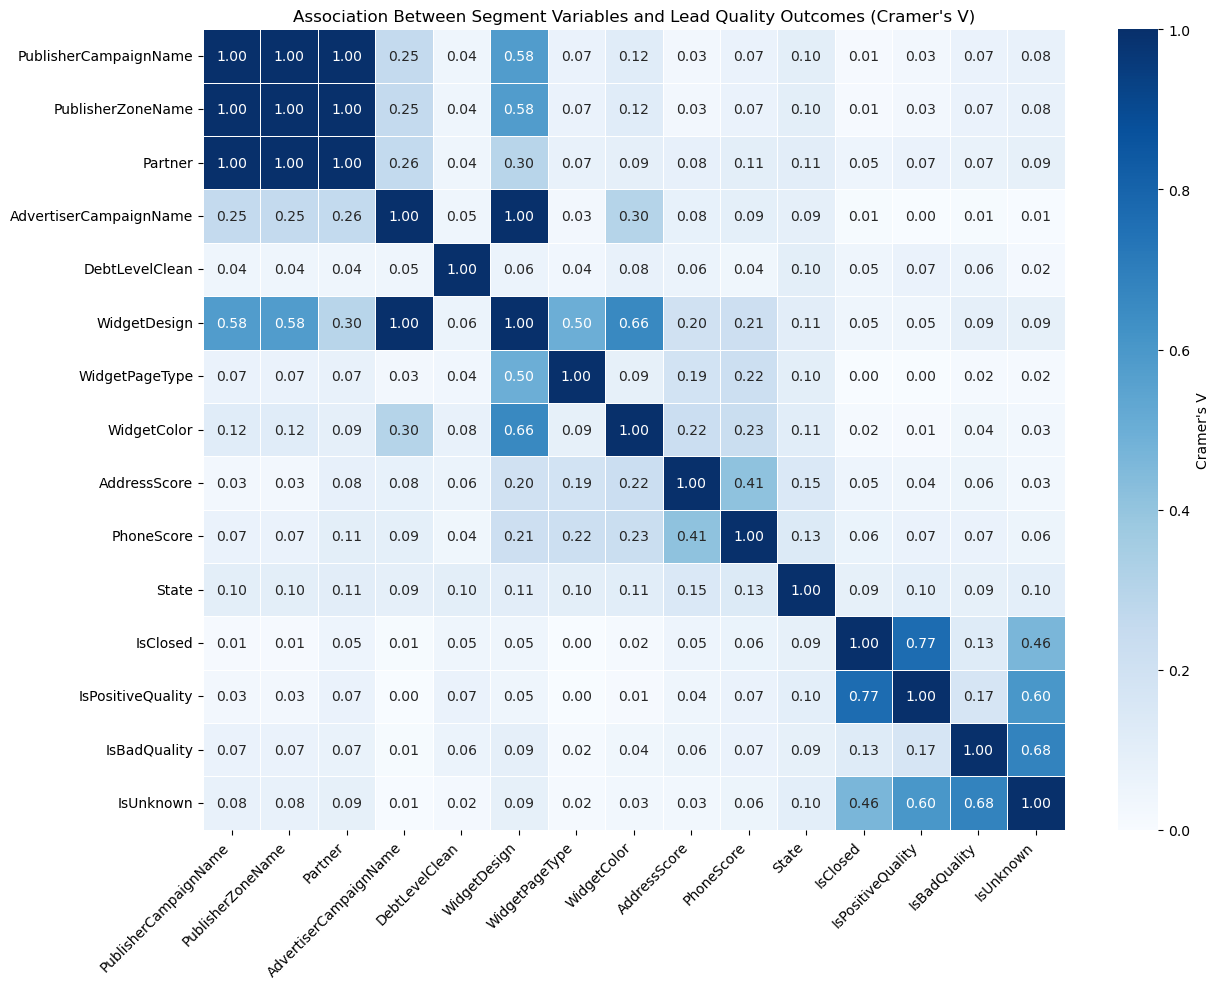

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 10))
sns.heatmap(
    cramers_v_matrix.astype(float),
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': "Cramer's V"}
)
plt.title("Association Between Segment Variables and Lead Quality Outcomes (Cramer's V)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [114]:
strong_associations = []
for i, col1 in enumerate(segment_variables):
    for col2 in segment_variables[i + 1:]:
        strong_associations.append({
            'variable_1': col1,
            'variable_2': col2,
            'cramers_v': cramers_v_matrix.loc[col1, col2]
        })

strong_associations = (
    pd.DataFrame(strong_associations)
    .sort_values('cramers_v', ascending=False)
    .reset_index(drop=True)
)

strong_associations.head(15)


,variable_1,variable_2,cramers_v
0,PublisherZoneName,Partner,1.000000
1,PublisherCampaignName,Partner,1.000000
2,AdvertiserCampaignName,WidgetDesign,1.000000
3,PublisherCampaignName,PublisherZoneName,0.997973
4,IsClosed,IsPositiveQuality,0.766417
5,IsBadQuality,IsUnknown,0.683072
6,WidgetDesign,WidgetColor,0.657996
7,IsPositiveQuality,IsUnknown,0.601593
8,PublisherCampaignName,WidgetDesign,0.579910
9,PublisherZoneName,WidgetDesign,0.579910


### Multivariate Driver Check

The segment summaries above are useful, but they are one-variable-at-a-time views. Some variables are also highly overlapping, so this section uses a simple multivariate logistic regression as a sanity check.

Variable selection logic:

- Keep one variable from each highly overlapping group. `PublisherCampaignName`, `PublisherZoneName`, and `Partner` are almost perfectly associated, so use `Partner` as the acquisition/channel variable.
- Do not include both `AdvertiserCampaignName` and `WidgetDesign`, because they are perfectly associated in this dataset. Use `WidgetDesign` because it is closer to the ad creative question.
- Do not include `WidgetColor` in the first model because it is strongly associated with `WidgetDesign`.
- Use `DebtLevelClean` for the consumer profile question.
- Use `PhoneScore` as a data-quality/profile signal, but group sparse raw scores before modeling because `PhoneScore = 1` has only one lead.
- Avoid high-cardinality variables such as keyword, referral URL, and landing page parameters in this first model because many categories would have very small sample sizes.

First model:

`IsPositiveQuality ~ PartnerModel + DebtLevelClean + WidgetDesign + PhoneScoreGroup`

Here, `IsPositiveQuality` means `Closed` or `Good Lead Quality` (`EP Sent`, `EP Received`, or `EP Confirmed`).

In [119]:
pd.crosstab(df['Partner'], df['WidgetDesign'])
pd.crosstab(df['Partner'], df['PhoneScore'].fillna('Missing'))
pd.crosstab(df['PhoneScore'].fillna('Missing'), df['IsPositiveQuality'])

IsPositiveQuality,0,1
PhoneScore,,
1.0,1,0
2.0,146,16
3.0,377,50
4.0,171,13
5.0,519,100
Missing,1413,214


In [120]:
pd.crosstab(df['Partner'], df['WidgetDesign'])
pd.crosstab(df['Partner'], df['PhoneScore'].fillna('Missing'))

PhoneScore,1.0,2.0,3.0,4.0,5.0,Missing
Partner,,,,,,
Adknowledge,0,4,25,4,32,106
Advertise.com,0,0,0,0,0,3
Call_center,0,19,56,15,42,139
Google,0,107,256,113,399,743
Yahoo,1,32,90,52,146,636


#### Model-ready Grouping

Before fitting the model, create grouped versions of variables with very small categories. This is only for modeling stability; the original columns remain unchanged.

Grouping logic:

- `Advertise.com` has only 3 leads, so it is grouped into `Other` in `PartnerModel`.
- `PhoneScore = 1` has only 1 lead, so raw phone scores are grouped into `High`, `Medium`, `Low`, and `Missing`.

In [125]:
model_df = df.copy()

model_df['PartnerModel'] = model_df['Partner'].fillna('Missing').astype(str)
partner_counts = model_df['PartnerModel'].value_counts()
small_partner_levels = partner_counts[partner_counts < 30].index
model_df['PartnerModel'] = model_df['PartnerModel'].where(
    ~model_df['PartnerModel'].isin(small_partner_levels),
    'Other'
)

def phone_score_group(score):
    if pd.isna(score):
        return 'Missing'
    if score == 5:
        return 'High'
    if score in [3, 4]:
        return 'Medium'
    if score in [1, 2]:
        return 'Low'
    return 'Other'

model_df['PhoneScoreGroup'] = model_df['PhoneScore'].apply(phone_score_group)
model_df['DebtLevelClean'] = model_df['DebtLevelClean'].fillna('Missing').astype(str)
model_df['WidgetDesign'] = model_df['WidgetDesign'].fillna('Missing').astype(str)

display(model_df['PartnerModel'].value_counts().rename_axis('PartnerModel').reset_index(name='leads'))
display(pd.crosstab(model_df['PhoneScoreGroup'], model_df['IsPositiveQuality']))


,PartnerModel,leads
0,Google,1618
1,Yahoo,957
2,Call_center,271
3,Adknowledge,171
4,Other,3


IsPositiveQuality,0,1
PhoneScoreGroup,,
High,519,100
Low,147,16
Medium,548,63
Missing,1413,214


In [126]:
import statsmodels.formula.api as smf

formula = (
    'IsPositiveQuality ~ '
    'C(PartnerModel, Treatment(reference="Google")) + '
    'C(DebtLevelClean, Treatment(reference="7500-15000")) + '
    'C(WidgetDesign, Treatment(reference="Base")) + '
    'C(PhoneScoreGroup, Treatment(reference="Missing"))'
)

positive_quality_model = smf.logit(formula=formula, data=model_df).fit(disp=False)
positive_quality_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:      IsPositiveQuality   No. Observations:                 3020
Model:                          Logit   Df Residuals:                     3002
Method:                           MLE   Df Model:                           17
Date:                Thu, 16 Jul 2026   Pseudo R-squ.:                 0.02056
Time:                        19:16:25   Log-Likelihood:                -1143.6
converged:                       True   LL-Null:                       -1167.6
Covariance Type:            nonrobust   LLR p-value:                 8.516e-05
=======================================================================================================================================
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                              -2.2785      0.193    -11.785      0.000      -2.657      -1.900
C(PartnerModel, Treatment(reference="Google"))[T.Adknowledge]           0.6232      0.215      2.904      0.004       0.203       1.044
C(PartnerModel, Treatment(reference="Google"))[T.Call_center]           0.5334      0.234      2.281      0.023       0.075       0.992
C(PartnerModel, Treatment(reference="Google"))[T.Other]                 1.3396      1.238      1.082      0.279      -1.087       3.767
C(PartnerModel, Treatment(reference="Google"))[T.Yahoo]                 0.2843      0.125      2.278      0.023       0.040       0.529
C(DebtLevelClean, Treatment(reference="7500-15000"))[T.15001-30000]     0.3066      0.139      2.207      0.027       0.034       0.579
C(DebtLevelClean, Treatment(reference="7500-15000"))[T.30001-50000]     0.0733      0.170      0.431      0.667      -0.260       0.407
C(DebtLevelClean, Treatment(reference="7500-15000"))[T.50001-90000]     0.4624      0.172      2.688      0.007       0.125       0.800
C(DebtLevelClean, Treatment(reference="7500-15000"))[T.90000+]         -0.3206      0.237     -1.354      0.176      -0.785       0.143
C(WidgetDesign, Treatment(reference="Base"))[T.BlueMeter]               0.1720      0.261      0.659      0.510      -0.339       0.683
C(WidgetDesign, Treatment(reference="Base"))[T.CreditSolutions]         0.0880      0.183      0.482      0.630      -0.270       0.446
C(WidgetDesign, Treatment(reference="Base"))[T.Head2]                   0.2278      0.329      0.693      0.489      -0.417       0.872
C(WidgetDesign, Treatment(reference="Base"))[T.Head3]                  -0.7188      0.487     -1.475      0.140      -1.674       0.237
C(WidgetDesign, Treatment(reference="Base"))[T.white]                  -0.1693      0.225     -0.751      0.452      -0.611       0.272
C(WidgetDesign, Treatment(reference="Base"))[T.yellowarrow]             0.2242      0.231      0.969      0.333      -0.229       0.678
C(PhoneScoreGroup, Treatment(reference="Missing"))[T.High]              0.2659      0.149      1.779      0.075      -0.027       0.559
C(PhoneScoreGroup, Treatment(reference="Missing"))[T.Low]              -0.3327      0.283     -1.175      0.240      -0.888       0.222
C(PhoneScoreGroup, Treatment(reference="Missing"))[T.Medium]           -0.2667      0.167     -1.601      0.109      -0.593       0.060
=======================================================================================================================================
"""

In [127]:
model_results = (
    pd.DataFrame({
        'coefficient': positive_quality_model.params,
        'p_value': positive_quality_model.pvalues
    })
    .drop(index='Intercept')
    .reset_index(names='term')
)

model_results['direction_vs_reference'] = np.where(
    model_results['coefficient'] > 0,
    'Higher positive quality',
    'Lower positive quality'
)
model_results['statistically_significant_0_05'] = model_results['p_value'] < 0.05

model_results.sort_values('p_value')


,term,coefficient,p_value,direction_vs_reference,statistically_significant_0_05
0,"C(PartnerModel, Treatment(reference=""Google""))...",0.623236,0.003688,Higher positive quality,True
6,"C(DebtLevelClean, Treatment(reference=""7500-15...",0.462447,0.007178,Higher positive quality,True
1,"C(PartnerModel, Treatment(reference=""Google""))...",0.533385,0.022562,Higher positive quality,True
3,"C(PartnerModel, Treatment(reference=""Google""))...",0.284333,0.022733,Higher positive quality,True
4,"C(DebtLevelClean, Treatment(reference=""7500-15...",0.306619,0.027286,Higher positive quality,True
14,"C(PhoneScoreGroup, Treatment(reference=""Missin...",0.265932,0.075241,Higher positive quality,False
16,"C(PhoneScoreGroup, Treatment(reference=""Missin...",-0.266734,0.109332,Lower positive quality,False
11,"C(WidgetDesign, Treatment(reference=""Base""))[T...",-0.718797,0.140318,Lower positive quality,False
7,"C(DebtLevelClean, Treatment(reference=""7500-15...",-0.320598,0.175696,Lower positive quality,False
15,"C(PhoneScoreGroup, Treatment(reference=""Missin...",-0.332745,0.240048,Lower positive quality,False


#### How to Read the Model

Each row compares one segment level against the reference level while controlling for the other variables in the model.

Reference levels:

- `PartnerModel`: `Google`
- `DebtLevelClean`: `7500-15000`
- `WidgetDesign`: `Base`
- `PhoneScoreGroup`: `Missing`

A positive coefficient means that segment has a higher modeled likelihood of positive lead quality than the reference group. A negative coefficient means lower. The p-value tells us whether the difference is statistically clear in this model.

### Driver Analysis Conclusion

The clearest drivers of positive lead quality in this dataset are **acquisition source/channel** and **consumer debt level**.

- **Where the ad was shown / where the lead came from:** `PublisherCampaignName`, `PublisherZoneName`, and `Partner` are highly overlapping, so use `PartnerModel` as the representative source/channel variable. `PartnerModel` is statistically significant in the multivariate model, which suggests that acquisition channel is one of the clearest lead quality drivers.
- **What kind of person filled out the ad:** `DebtLevelClean` remains statistically significant after controlling for the other variables. This is the strongest consumer-profile signal. Leads with higher debt ranges show better positive quality than the lowest debt reference group (`7500-15000`).
- **What kind of ad they saw:** `WidgetDesign` shows descriptive differences, but it is not statistically significant after controlling for partner, debt level, and phone score. This means the creative differences may be partly confounded with traffic source or campaign setup, so we should not treat widget design as a clean independent driver based on this model.

`PhoneScoreGroup` shows some directional signal, but it is not statistically significant at the 0.05 level in this model. Overall, the model is statistically significant, but the pseudo R-squared is low, so these variables explain some lead quality differences but do not fully explain lead quality.

## CPL Opportunity Analysis

The prompt says the advertiser would increase CPL if lead quality improves by 20%, from `8.0%` to `9.6%`. Since the dataset's overall Closed Rate is about 8%, this section treats **Closed Rate** as the main lead quality metric for the CPL opportunity analysis.

Goal:

`Target Closed Rate = Current Closed Rate * 1.20`


In [132]:
quality_lift_target = 1.20

total_leads = len(df)
closed_leads = df['IsClosed'].sum()
baseline_closed_rate = df['IsClosed'].mean()
target_closed_rate = baseline_closed_rate * quality_lift_target
required_closed_leads_at_current_volume = np.ceil(total_leads * target_closed_rate).astype(int)
additional_closed_leads_needed = required_closed_leads_at_current_volume - closed_leads

closed_rate_target_baseline = pd.DataFrame({
    'metric': [
        'Total leads',
        'Closed leads',
        'Current Closed Rate',
        'Target Closed Rate',
        'Required closed leads at current volume',
        'Additional closed leads needed'
    ],
    'value': [
        total_leads,
        closed_leads,
        baseline_closed_rate * 100,
        target_closed_rate * 100,
        required_closed_leads_at_current_volume,
        additional_closed_leads_needed
    ]
})

closed_rate_target_baseline


,metric,value
0,Total leads,3020.000000
1,Closed leads,245.000000
2,Current Closed Rate,8.112583
3,Target Closed Rate,9.735099
4,Required closed leads at current volume,294.000000
5,Additional closed leads needed,49.000000


### Segment Opportunity Screen

Start with the two clearest driver areas from the previous section: acquisition/source channel and consumer debt level. The goal is to identify segments with Closed Rate above the target while also keeping enough lead volume to matter.

Use `min_leads = 30` so that extremely small segments are not treated as meaningful opportunities.

In [133]:
opportunity_df = df.copy()

if 'IsClosed' not in opportunity_df.columns:
    opportunity_df['IsClosed'] = (opportunity_df['CallStatusGroup'] == 'Closed').astype(int)

if 'target_closed_rate' not in globals():
    target_closed_rate = opportunity_df['IsClosed'].mean() * 1.20

opportunity_df['PartnerModel'] = opportunity_df['Partner'].fillna('Missing').astype(str)
partner_counts = opportunity_df['PartnerModel'].value_counts()
small_partner_levels = partner_counts[partner_counts < 30].index
opportunity_df['PartnerModel'] = opportunity_df['PartnerModel'].where(
    ~opportunity_df['PartnerModel'].isin(small_partner_levels),
    'Other'
)

def closed_rate_opportunity(segment_col, min_leads=30):
    summary = (
        opportunity_df.groupby(segment_col, dropna=False)
        .agg(
            leads=('IsClosed', 'size'),
            closed_leads=('IsClosed', 'sum'),
            closed_rate=('IsClosed', 'mean')
        )
        .reset_index()
    )
    summary = summary[summary['leads'] >= min_leads].copy()
    summary['closed_rate_pct'] = summary['closed_rate'] * 100
    summary['volume_share_pct'] = summary['leads'] / len(opportunity_df) * 100
    summary['above_target'] = summary['closed_rate'] >= target_closed_rate
    return summary.sort_values(['above_target', 'closed_rate', 'leads'], ascending=[False, False, False])

display(closed_rate_opportunity('PartnerModel'))
display(closed_rate_opportunity('DebtLevelClean'))


,PartnerModel,leads,closed_leads,closed_rate,closed_rate_pct,volume_share_pct,above_target
0,Adknowledge,171,21,0.122807,12.280702,5.662252,True
1,Call_center,271,26,0.095941,9.594096,8.973510,False
4,Yahoo,957,74,0.077325,7.732497,31.688742,False
2,Google,1618,123,0.076020,7.601978,53.576159,False


,DebtLevelClean,leads,closed_leads,closed_rate,closed_rate_pct,volume_share_pct,above_target
2,50001-90000,376,40,0.106383,10.638298,12.450331,True
0,15001-30000,864,75,0.086806,8.680556,28.609272,False
1,30001-50000,496,39,0.078629,7.862903,16.423841,False
3,7500-15000,1004,75,0.074701,7.470120,33.245033,False
4,90000+,280,16,0.057143,5.714286,9.271523,False


### Scenario Analysis: Quality Lift vs Revenue Tradeoff

Now test practical filtering or mix-shift scenarios. For each scenario, compare the remaining lead volume, Closed Rate, whether it reaches the target, and revenue if the advertiser pays the proposed `$33` CPL.

This helps distinguish a real opportunity from a scenario that improves quality only by cutting too much volume.

In [134]:
current_cpl = 30
proposed_cpl = 33
current_revenue = len(opportunity_df) * current_cpl

scenario_definitions = {
    'Baseline: all leads': opportunity_df.index == opportunity_df.index,
    'Keep only Adknowledge': opportunity_df['PartnerModel'] == 'Adknowledge',
    'Keep only DebtLevel 50001-90000': opportunity_df['DebtLevelClean'] == '50001-90000',
    'Exclude low-performing debt levels': ~opportunity_df['DebtLevelClean'].isin(['7500-15000', '90000+']),
    'Keep debt levels 15001-90000': opportunity_df['DebtLevelClean'].isin(['15001-30000', '30001-50000', '50001-90000']),
    'Keep Adknowledge or DebtLevel 50001-90000': (
        (opportunity_df['PartnerModel'] == 'Adknowledge')
        | (opportunity_df['DebtLevelClean'] == '50001-90000')
    ),
    'Keep Adknowledge or Call_center or DebtLevel 50001-90000': (
        opportunity_df['PartnerModel'].isin(['Adknowledge', 'Call_center'])
        | (opportunity_df['DebtLevelClean'] == '50001-90000')
    )
}

scenario_rows = []
for scenario_name, mask in scenario_definitions.items():
    scenario_data = opportunity_df[mask].copy()
    scenario_leads = len(scenario_data)
    scenario_closed = scenario_data['IsClosed'].sum()
    scenario_closed_rate = scenario_data['IsClosed'].mean() if scenario_leads > 0 else np.nan
    scenario_revenue_at_33 = scenario_leads * proposed_cpl

    scenario_rows.append({
        'scenario': scenario_name,
        'leads_kept': scenario_leads,
        'volume_retained_pct': scenario_leads / len(opportunity_df) * 100,
        'closed_leads': scenario_closed,
        'closed_rate_pct': scenario_closed_rate * 100,
        'hit_target': scenario_closed_rate >= target_closed_rate,
        'revenue_at_33': scenario_revenue_at_33,
        'revenue_change_vs_current_30': scenario_revenue_at_33 - current_revenue,
        'revenue_change_pct': (scenario_revenue_at_33 / current_revenue - 1) * 100
    })

scenario_analysis = pd.DataFrame(scenario_rows)
scenario_analysis


,scenario,leads_kept,volume_retained_pct,closed_leads,closed_rate_pct,hit_target,revenue_at_33,revenue_change_vs_current_30,revenue_change_pct
0,Baseline: all leads,3020,100.000000,245,8.112583,False,99660,9060,10.000000
1,Keep only Adknowledge,171,5.662252,21,12.280702,True,5643,-84957,-93.771523
2,Keep only DebtLevel 50001-90000,376,12.450331,40,10.638298,True,12408,-78192,-86.304636
3,Exclude low-performing debt levels,1736,57.483444,154,8.870968,False,57288,-33312,-36.768212
4,Keep debt levels 15001-90000,1736,57.483444,154,8.870968,False,57288,-33312,-36.768212
5,Keep Adknowledge or DebtLevel 50001-90000,534,17.682119,59,11.048689,True,17622,-72978,-80.549669
6,Keep Adknowledge or Call_center or DebtLevel 5...,770,25.496689,84,10.909091,True,25410,-65190,-71.953642


### Relaxed Filter Scenario

Strict filtering can raise Closed Rate above the target, but it removes too much volume. A more realistic strategy is to keep all leads that pass a high-quality filter, then randomly allow some leads from the non-pass group back in until the expected Closed Rate is just at the target.

This assumes the added-back leads perform like the historical non-pass group on average.

In [135]:
relaxed_filter_definitions = {
    'Pass if Adknowledge': opportunity_df['PartnerModel'] == 'Adknowledge',
    'Pass if DebtLevel 50001-90000': opportunity_df['DebtLevelClean'] == '50001-90000',
    'Pass if Adknowledge or DebtLevel 50001-90000': (
        (opportunity_df['PartnerModel'] == 'Adknowledge')
        | (opportunity_df['DebtLevelClean'] == '50001-90000')
    ),
    'Pass if Adknowledge or Call_center or DebtLevel 50001-90000': (
        opportunity_df['PartnerModel'].isin(['Adknowledge', 'Call_center'])
        | (opportunity_df['DebtLevelClean'] == '50001-90000')
    )
}

relaxed_rows = []
for scenario_name, pass_mask in relaxed_filter_definitions.items():
    pass_group = opportunity_df[pass_mask]
    fail_group = opportunity_df[~pass_mask]

    pass_leads = len(pass_group)
    pass_closed = pass_group['IsClosed'].sum()
    pass_closed_rate = pass_group['IsClosed'].mean()

    fail_leads = len(fail_group)
    fail_closed_rate = fail_group['IsClosed'].mean()

    # Solve for x: (pass_closed + x * fail_closed_rate) / (pass_leads + x) >= target_closed_rate
    if pass_closed_rate < target_closed_rate or fail_closed_rate >= target_closed_rate:
        max_fail_leads_added = 0
    else:
        max_fail_leads_added = np.floor(
            (pass_closed - target_closed_rate * pass_leads)
            / (target_closed_rate - fail_closed_rate)
        ).astype(int)
        max_fail_leads_added = max(0, min(max_fail_leads_added, fail_leads))

    total_leads_after_relaxing = pass_leads + max_fail_leads_added
    expected_closed_after_relaxing = pass_closed + max_fail_leads_added * fail_closed_rate
    expected_closed_rate_after_relaxing = expected_closed_after_relaxing / total_leads_after_relaxing
    revenue_at_33 = total_leads_after_relaxing * proposed_cpl

    relaxed_rows.append({
        'scenario': scenario_name,
        'pass_leads': pass_leads,
        'pass_closed_rate_pct': pass_closed_rate * 100,
        'fail_closed_rate_pct': fail_closed_rate * 100,
        'max_fail_leads_added_back': max_fail_leads_added,
        'total_leads_retained': total_leads_after_relaxing,
        'volume_retained_pct': total_leads_after_relaxing / len(opportunity_df) * 100,
        'expected_closed_rate_pct': expected_closed_rate_after_relaxing * 100,
        'hit_target': expected_closed_rate_after_relaxing >= target_closed_rate,
        'revenue_at_33': revenue_at_33,
        'revenue_change_vs_current_30': revenue_at_33 - current_revenue,
        'revenue_change_pct': (revenue_at_33 / current_revenue - 1) * 100
    })

relaxed_filter_analysis = pd.DataFrame(relaxed_rows)
relaxed_filter_analysis


,scenario,pass_leads,pass_closed_rate_pct,fail_closed_rate_pct,max_fail_leads_added_back,total_leads_retained,volume_retained_pct,expected_closed_rate_pct,hit_target,revenue_at_33,revenue_change_vs_current_30,revenue_change_pct
0,Pass if Adknowledge,171,12.280702,7.862408,232,403,13.344371,9.737168,True,13299,-77301,-85.321192
1,Pass if DebtLevel 50001-90000,376,10.638298,7.753404,171,547,18.112583,9.736439,True,18051,-72549,-80.076159
2,Pass if Adknowledge or DebtLevel 50001-90000,534,11.048689,7.481899,311,845,27.980132,9.735941,True,27885,-62715,-69.221854
3,Pass if Adknowledge or Call_center or DebtLeve...,770,10.909091,7.155556,350,1120,37.086093,9.736111,True,36960,-53640,-59.205298


### Remove Worst Segment Scenario

Another practical option is to remove only the weakest segments rather than keeping only the strongest ones. This simulation removes segments one at a time from lowest historical Closed Rate to highest, then recalculates the remaining Closed Rate, volume, and revenue.

This is still a historical backtest, so it should be treated as directional rather than guaranteed future performance.

In [136]:
def remove_worst_segments(segment_col, min_segment_leads=30):
    segment_rates = (
        opportunity_df.groupby(segment_col, dropna=False)
        .agg(
            segment_leads=('IsClosed', 'size'),
            segment_closed_leads=('IsClosed', 'sum'),
            segment_closed_rate=('IsClosed', 'mean')
        )
        .reset_index()
    )
    segment_rates = segment_rates[segment_rates['segment_leads'] >= min_segment_leads].copy()
    segment_rates = segment_rates.sort_values('segment_closed_rate')

    removed_segments = []
    rows = []

    for _, row in segment_rates.iterrows():
        removed_segments.append(row[segment_col])
        remaining = opportunity_df[~opportunity_df[segment_col].isin(removed_segments)]
        remaining_leads = len(remaining)
        remaining_closed = remaining['IsClosed'].sum()
        remaining_closed_rate = remaining['IsClosed'].mean() if remaining_leads > 0 else np.nan
        revenue_at_33 = remaining_leads * proposed_cpl

        rows.append({
            'segment_col': segment_col,
            'removed_segments': ', '.join(map(str, removed_segments)),
            'removed_step': row[segment_col],
            'remaining_leads': remaining_leads,
            'volume_retained_pct': remaining_leads / len(opportunity_df) * 100,
            'remaining_closed_leads': remaining_closed,
            'remaining_closed_rate_pct': remaining_closed_rate * 100,
            'hit_target': remaining_closed_rate >= target_closed_rate,
            'revenue_at_33': revenue_at_33,
            'revenue_change_vs_current_30': revenue_at_33 - current_revenue,
            'revenue_change_pct': (revenue_at_33 / current_revenue - 1) * 100
        })

    return pd.DataFrame(rows)

remove_worst_partner = remove_worst_segments('PartnerModel')
remove_worst_debt = remove_worst_segments('DebtLevelClean')

display(remove_worst_partner)
display(remove_worst_debt)


,segment_col,removed_segments,removed_step,remaining_leads,volume_retained_pct,remaining_closed_leads,remaining_closed_rate_pct,hit_target,revenue_at_33,revenue_change_vs_current_30,revenue_change_pct
0,PartnerModel,Google,Google,1402,46.423841,122,8.701854,False,46266,-44334,-48.933775
1,PartnerModel,"Google, Yahoo",Yahoo,445,14.735099,48,10.786517,True,14685,-75915,-83.791391
2,PartnerModel,"Google, Yahoo, Call_center",Call_center,174,5.761589,22,12.643678,True,5742,-84858,-93.662252
3,PartnerModel,"Google, Yahoo, Call_center, Adknowledge",Adknowledge,3,0.099338,1,33.333333,True,99,-90501,-99.890728


,segment_col,removed_segments,removed_step,remaining_leads,volume_retained_pct,remaining_closed_leads,remaining_closed_rate_pct,hit_target,revenue_at_33,revenue_change_vs_current_30,revenue_change_pct
0,DebtLevelClean,90000+,90000+,2740,90.728477,229,8.357664,False,90420,-180,-0.198675
1,DebtLevelClean,"90000+, 7500-15000",7500-15000,1736,57.483444,154,8.870968,False,57288,-33312,-36.768212
2,DebtLevelClean,"90000+, 7500-15000, 30001-50000",30001-50000,1240,41.059603,115,9.274194,False,40920,-49680,-54.834437
3,DebtLevelClean,"90000+, 7500-15000, 30001-50000, 15001-30000",15001-30000,376,12.450331,40,10.638298,True,12408,-78192,-86.304636
4,DebtLevelClean,"90000+, 7500-15000, 30001-50000, 15001-30000, ...",50001-90000,0,0.000000,0,NaN,False,0,-90600,-100.000000


### CPL Opportunity Conclusion

The data shows some segments with Closed Rates above the target, especially `Adknowledge` and `DebtLevelClean = 50001-90000`. However, these segments are relatively small.

The scenario analysis shows that **hard filtering alone is not economically attractive**. Some filtering rules can reach the target Closed Rate, but they retain too little lead volume. Because CPL only increases from `$30` to `$33`, we would need to keep roughly 91% of current volume for revenue to break even. The target-hitting scenarios keep far less volume than that.

The remove-worst analysis leads to the same conclusion. Removing only `DebtLevelClean = 90000+` is a low-risk improvement because it keeps about 91% of volume and nearly breaks even on revenue, but it only raises Closed Rate to about 8.36%, below the target. To actually hit the target, we still have to remove too much volume.

This is also affected by missingness and sparse segments. Several quality-related fields have many missing values or small high-performing groups, so strict filtering would exclude too many leads.

The better opportunity is not to simply cut leads, but to **shift the traffic mix and test scaling higher-quality segments**:

- Try to increase volume from higher-performing sources such as `Adknowledge`, while validating whether quality holds as volume scales.
- Prioritize or bid more aggressively for stronger debt ranges, especially `50001-90000`.
- Reduce, improve, or separately price weaker segments rather than fully removing them.
- Treat missing or low-coverage quality scores as soft signals, not hard filters.

Overall, there are quality-improvement opportunities, but reaching the CPL incentive likely requires mix optimization and testing rather than simple lead filtering.


### Secondary Check: Positive Quality Rate

Closed Rate is the primary metric for the CPL question because it matches the prompt's `8.0%` baseline. As a secondary check, repeat the baseline and segment screen using the broader Positive Quality Rate.

`Positive Quality Rate = Closed + Good Lead Quality leads / total leads`

In [137]:
positive_quality_lift_multiplier = 1.20

positive_quality_leads = df['IsPositiveQuality'].sum()
baseline_positive_quality_rate = df['IsPositiveQuality'].mean()
target_positive_quality_rate = baseline_positive_quality_rate * positive_quality_lift_multiplier
required_positive_quality_leads_at_current_volume = np.ceil(len(df) * target_positive_quality_rate).astype(int)
additional_positive_quality_leads_needed = required_positive_quality_leads_at_current_volume - positive_quality_leads

positive_quality_target_baseline = pd.DataFrame({
    'metric': [
        'Total leads',
        'Positive quality leads',
        'Current Positive Quality Rate',
        'Lift multiplier',
        'Target Positive Quality Rate',
        'Required positive quality leads at current volume',
        'Additional positive quality leads needed'
    ],
    'value': [
        len(df),
        positive_quality_leads,
        baseline_positive_quality_rate * 100,
        positive_quality_lift_multiplier,
        target_positive_quality_rate * 100,
        required_positive_quality_leads_at_current_volume,
        additional_positive_quality_leads_needed
    ]
})

positive_quality_target_baseline


,metric,value
0,Total leads,3020.000000
1,Positive quality leads,393.000000
2,Current Positive Quality Rate,13.013245
3,Lift multiplier,1.200000
4,Target Positive Quality Rate,15.615894
5,Required positive quality leads at current volume,472.000000
6,Additional positive quality leads needed,79.000000


In [138]:
def positive_quality_opportunity(segment_col, min_leads=30):
    summary = (
        opportunity_df.groupby(segment_col, dropna=False)
        .agg(
            leads=('IsPositiveQuality', 'size'),
            positive_quality_leads=('IsPositiveQuality', 'sum'),
            positive_quality_rate=('IsPositiveQuality', 'mean')
        )
        .reset_index()
    )
    summary = summary[summary['leads'] >= min_leads].copy()
    summary['positive_quality_rate_pct'] = summary['positive_quality_rate'] * 100
    summary['volume_share_pct'] = summary['leads'] / len(opportunity_df) * 100
    summary['above_target'] = summary['positive_quality_rate'] >= target_positive_quality_rate
    return summary.sort_values(['above_target', 'positive_quality_rate', 'leads'], ascending=[False, False, False])

display(positive_quality_opportunity('PartnerModel'))
display(positive_quality_opportunity('DebtLevelClean'))


,PartnerModel,leads,positive_quality_leads,positive_quality_rate,positive_quality_rate_pct,volume_share_pct,above_target
0,Adknowledge,171,32,0.187135,18.713450,5.662252,True
1,Call_center,271,44,0.162362,16.236162,8.973510,True
4,Yahoo,957,136,0.142111,14.211076,31.688742,False
2,Google,1618,180,0.111248,11.124845,53.576159,False


,DebtLevelClean,leads,positive_quality_leads,positive_quality_rate,positive_quality_rate_pct,volume_share_pct,above_target
2,50001-90000,376,63,0.167553,16.755319,12.450331,True
0,15001-30000,864,129,0.149306,14.930556,28.609272,False
1,30001-50000,496,61,0.122984,12.298387,16.423841,False
3,7500-15000,1004,116,0.115538,11.553785,33.245033,False
4,90000+,280,24,0.085714,8.571429,9.271523,False


#### Remove Worst Segments: Positive Quality Rate

Repeat the remove-worst scenario using Positive Quality Rate as the outcome. This checks whether filtering out the weakest segments can reach a 20% lift on the broader quality metric.

In [139]:
def remove_worst_segments_positive_quality(segment_col, min_segment_leads=30):
    segment_rates = (
        opportunity_df.groupby(segment_col, dropna=False)
        .agg(
            segment_leads=('IsPositiveQuality', 'size'),
            segment_positive_quality_leads=('IsPositiveQuality', 'sum'),
            segment_positive_quality_rate=('IsPositiveQuality', 'mean')
        )
        .reset_index()
    )
    segment_rates = segment_rates[segment_rates['segment_leads'] >= min_segment_leads].copy()
    segment_rates = segment_rates.sort_values('segment_positive_quality_rate')

    removed_segments = []
    rows = []

    for _, row in segment_rates.iterrows():
        removed_segments.append(row[segment_col])
        remaining = opportunity_df[~opportunity_df[segment_col].isin(removed_segments)]
        remaining_leads = len(remaining)
        remaining_positive_quality = remaining['IsPositiveQuality'].sum()
        remaining_positive_quality_rate = remaining['IsPositiveQuality'].mean() if remaining_leads > 0 else np.nan
        revenue_at_33 = remaining_leads * proposed_cpl

        rows.append({
            'segment_col': segment_col,
            'removed_segments': ', '.join(map(str, removed_segments)),
            'removed_step': row[segment_col],
            'remaining_leads': remaining_leads,
            'volume_retained_pct': remaining_leads / len(opportunity_df) * 100,
            'remaining_positive_quality_leads': remaining_positive_quality,
            'remaining_positive_quality_rate_pct': remaining_positive_quality_rate * 100,
            'hit_target': remaining_positive_quality_rate >= target_positive_quality_rate,
            'revenue_at_33': revenue_at_33,
            'revenue_change_vs_current_30': revenue_at_33 - current_revenue,
            'revenue_change_pct': (revenue_at_33 / current_revenue - 1) * 100
        })

    return pd.DataFrame(rows)

remove_worst_partner_positive = remove_worst_segments_positive_quality('PartnerModel')
remove_worst_debt_positive = remove_worst_segments_positive_quality('DebtLevelClean')

display(remove_worst_partner_positive)
display(remove_worst_debt_positive)


,segment_col,removed_segments,removed_step,remaining_leads,volume_retained_pct,remaining_positive_quality_leads,remaining_positive_quality_rate_pct,hit_target,revenue_at_33,revenue_change_vs_current_30,revenue_change_pct
0,PartnerModel,Google,Google,1402,46.423841,213,15.192582,False,46266,-44334,-48.933775
1,PartnerModel,"Google, Yahoo",Yahoo,445,14.735099,77,17.303371,True,14685,-75915,-83.791391
2,PartnerModel,"Google, Yahoo, Call_center",Call_center,174,5.761589,33,18.965517,True,5742,-84858,-93.662252
3,PartnerModel,"Google, Yahoo, Call_center, Adknowledge",Adknowledge,3,0.099338,1,33.333333,True,99,-90501,-99.890728


,segment_col,removed_segments,removed_step,remaining_leads,volume_retained_pct,remaining_positive_quality_leads,remaining_positive_quality_rate_pct,hit_target,revenue_at_33,revenue_change_vs_current_30,revenue_change_pct
0,DebtLevelClean,90000+,90000+,2740,90.728477,369,13.467153,False,90420,-180,-0.198675
1,DebtLevelClean,"90000+, 7500-15000",7500-15000,1736,57.483444,253,14.573733,False,57288,-33312,-36.768212
2,DebtLevelClean,"90000+, 7500-15000, 30001-50000",30001-50000,1240,41.059603,192,15.483871,False,40920,-49680,-54.834437
3,DebtLevelClean,"90000+, 7500-15000, 30001-50000, 15001-30000",15001-30000,376,12.450331,63,16.755319,True,12408,-78192,-86.304636
4,DebtLevelClean,"90000+, 7500-15000, 30001-50000, 15001-30000, ...",50001-90000,0,0.000000,0,NaN,False,0,-90600,-100.000000
